# Topic Modeling con BERTopic, LDA y NMF

Notebook inspirado en `ella.ipynb`, pero adaptado a `data.csv` (dataset local).


## 0. Setup e instalación


In [3]:
# Si falta algo, descomenta:
# !pip install numpy pandas matplotlib seaborn scikit-learn nltk gensim bertopic sentence-transformers umap-learn hdbscan

import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 1. Carga y Exploración del Dataset


In [38]:
df = pd.read_csv("data.csv")
print("Shape:", df.shape)
display(df.head(3))


Shape: (168639, 7)


,id,name,overview,number_of_seasons,number_of_episodes,genres,created_by
0,1399,Game of Thrones,Seven noble families fight for control of the ...,8,73,"Sci-Fi & Fantasy, Drama, Action & Adventure","David Benioff, D.B. Weiss"
1,71446,Money Heist,"To carry out the biggest heist in history, a m...",3,41,"Crime, Drama",Álex Pina
2,66732,Stranger Things,"When a young boy vanishes, a small town uncove...",4,34,"Drama, Sci-Fi & Fantasy, Mystery","Matt Duffer, Ross Duffer"


In [39]:
text_candidates = ["overview", "genres", "created_by", "name"]
text_col = next((c for c in text_candidates if c in df.columns), None)
if text_col is None:
    raise ValueError(f"No encontré columna textual entre: {text_candidates}")

print("Columna de texto usada:", text_col)
print("Shape inicial:", df.shape)
print("Nulos en texto:", df[text_col].isna().sum())
print("Duplicados:", df.duplicated().sum())

df = df.drop_duplicates().copy()
print("Después de eliminar duplicados:", df.shape)

df = df[df[text_col].notna()].copy()
print("Después de eliminar nulos en text_col:", df.shape)

df[text_col] = df[text_col].astype(str).str.strip()
df = df[df[text_col].str.len() > 0].copy()
print("Después de eliminar strings vacíos en text_col:", df.shape)

# Eliminar filas con genres, overview o name vacíos
print("Nulos en genres:", df['genres'].isna().sum())
print("Nulos en overview:", df['overview'].isna().sum())
print("Nulos en name:", df['name'].isna().sum())

df = df[df['genres'].notna() & df['genres'].astype(str).str.strip().str.len() > 0].copy()
print("Después de eliminar vacíos en genres:", df.shape)

if text_col != 'overview':
    df = df[df['overview'].notna() & df['overview'].astype(str).str.strip().str.len() > 0].copy()
    print("Después de eliminar vacíos en overview:", df.shape)

df = df[df['name'].notna() & df['name'].astype(str).str.strip().str.len() > 0].copy()
print("Después de eliminar vacíos en name:", df.shape)

print("Shape limpio:", df.shape)

Columna de texto usada: overview
Shape inicial: (168639, 7)
Nulos en texto: 75306
Duplicados: 3631
Después de eliminar duplicados: (165008, 7)
Después de eliminar nulos en text_col: (91801, 7)
Después de eliminar strings vacíos en text_col: (91785, 7)
Nulos en genres: 28486
Valores únicos en genres (top 10): genres
NaN                  28486
Drama                10485
Documentary           9283
Comedy                6652
Reality               4672
Animation             2216
Comedy, Drama         1511
Drama, Comedy         1406
Animation, Comedy     1058
Crime, Drama           789
Name: count, dtype: int64
Strings vacíos en genres: 0
Nulos en overview: 0
Nulos en name: 0
Después de eliminar vacíos en genres: (43762, 7)
Después de eliminar vacíos en name: (21878, 7)
Shape limpio: (21878, 7)


min: 1
max: 1839
media: 57.81
mediana: 44.0


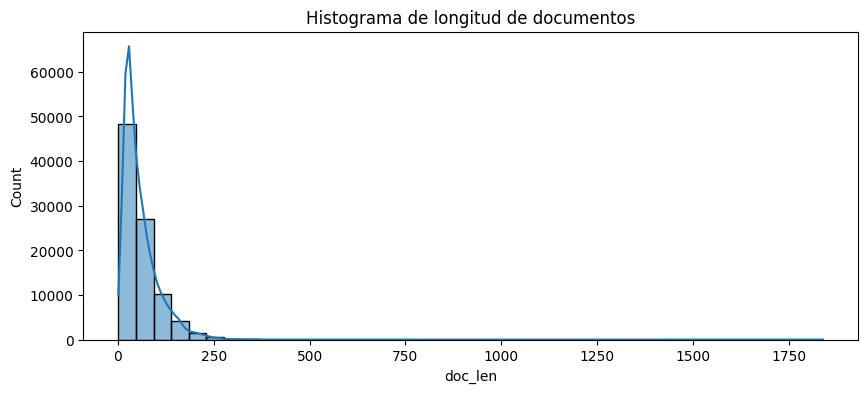

In [13]:
df["doc_len"] = df[text_col].str.split().str.len()
print("min:", int(df["doc_len"].min()))
print("max:", int(df["doc_len"].max()))
print("media:", round(float(df["doc_len"].mean()),2))
print("mediana:", round(float(df["doc_len"].median()),2))

plt.figure(figsize=(10,4))
sns.histplot(df["doc_len"], bins=40, kde=True)
plt.title("Histograma de longitud de documentos")
plt.show()


In [14]:
tokens_raw = re.findall(r"[A-Za-zÀ-ÿ]+", " ".join(df[text_col].tolist()).lower())
common30 = pd.DataFrame(Counter(tokens_raw).most_common(30), columns=["word","freq"])
display(common30)


,word,freq
0,the,327048
1,and,179222
2,a,157625
3,of,147322
4,to,121200
5,in,106544
6,is,77295
7,on,67633
8,s,51680
9,by,47192


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91710 entries, 0 to 168637
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  91710 non-null  int64 
 1   name                91710 non-null  object
 2   overview            91710 non-null  object
 3   number_of_seasons   91710 non-null  int64 
 4   number_of_episodes  91710 non-null  int64 
 5   genres              63271 non-null  object
 6   created_by          25389 non-null  object
 7   doc_len             91710 non-null  int64 
 8   docs_clean          91710 non-null  object
 9   docs_bert           91710 non-null  object
dtypes: int64(4), object(6)
memory usage: 7.7+ MB


## 2. Preprocesamiento de Texto


In [8]:
stop_words = set(stopwords.words("english"))
custom_stopwords = set()  # añade aquí stopwords de dominio
all_stopwords = stop_words.union(custom_stopwords)
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    toks = [w for w in text.split() if len(w) > 2 and w not in all_stopwords]
    return " ".join(lemmatizer.lemmatize(t) for t in toks)

def preprocess_bert(text):
    # limpieza mínima para preservar contexto
    return re.sub(r"\s+", " ", str(text)).strip()

df["docs_clean"] = df[text_col].apply(preprocess)
df["docs_bert"] = df[text_col].apply(preprocess_bert)
df = df[df["docs_clean"].str.len() > 0].copy()

display(df[[text_col, "docs_clean", "docs_bert"]].head(3))


,overview,docs_clean,docs_bert
0,Seven noble families fight for control of the ...,seven noble family fight control mythical land...,Seven noble families fight for control of the ...
1,"To carry out the biggest heist in history, a m...",carry biggest heist history mysterious man cal...,"To carry out the biggest heist in history, a m..."
2,"When a young boy vanishes, a small town uncove...",young boy vanishes small town uncovers mystery...,"When a young boy vanishes, a small town uncove..."


## 3. LDA — baseline con selección de K


In [9]:
def top_words(model, feature_names, n=10):
    return [[feature_names[i] for i in comp.argsort()[-n:][::-1]] for comp in model.components_]

vectorizer_lda = CountVectorizer(max_df=0.9, min_df=5)
X_lda = vectorizer_lda.fit_transform(df["docs_clean"])
fn_lda = vectorizer_lda.get_feature_names_out()

tokenized = [d.split() for d in df["docs_clean"].tolist()]
dictionary = Dictionary(tokenized)


In [10]:
# Barrido de K solicitado: 2..25
lda_search=[]
for k in range(2,26):
    lda_k = LatentDirichletAllocation(n_components=k, random_state=42, learning_method="batch", max_iter=15)
    lda_k.fit(X_lda)
    topics_k = top_words(lda_k, fn_lda, n=10)
    cv = CoherenceModel(topics=topics_k, texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()
    lda_search.append({"k":k, "coherence_cv":cv, "perplexity":lda_k.perplexity(X_lda)})

lda_search = pd.DataFrame(lda_search)
best_k = int(lda_search.loc[lda_search.coherence_cv.idxmax(), "k"])
display(lda_search)
print("Mejor K (coherence c_v):", best_k)


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(lda_search["k"], lda_search["coherence_cv"], marker="o", label="coherence c_v")
plt.plot(lda_search["k"], lda_search["perplexity"], marker="s", label="perplexity")
plt.title("Selección de K para LDA")
plt.xlabel("K")
plt.legend()
plt.grid(alpha=.3)
plt.show()


In [ ]:
lda = LatentDirichletAllocation(n_components=best_k, random_state=42, learning_method="batch", max_iter=20)
lda.fit(X_lda)
lda_doc_topic = lda.transform(X_lda)
df["topic_lda"] = lda_doc_topic.argmax(axis=1)

sizes_lda = df["topic_lda"].value_counts().head(5)
words_lda = top_words(lda, fn_lda, n=10)
for t in sizes_lda.index:
    print(f"Tópico LDA {t}:", ", ".join(words_lda[t]))


## 4. NMF — baseline


In [ ]:
vectorizer_nmf = TfidfVectorizer(max_df=0.9, min_df=5)
X_nmf = vectorizer_nmf.fit_transform(df["docs_clean"])
fn_nmf = vectorizer_nmf.get_feature_names_out()

nmf_search=[]
for k in range(10,31):
    nmf_k = NMF(n_components=k, random_state=42, init="nndsvda", max_iter=500)
    W_k = nmf_k.fit_transform(X_nmf)
    topics_k = top_words(nmf_k, fn_nmf, n=10)
    cv = CoherenceModel(topics=topics_k, texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()
    nmf_search.append({"k":k, "coherence_cv":cv, "reconstruction_err":nmf_k.reconstruction_err_})

nmf_search = pd.DataFrame(nmf_search)
best_k_nmf = int(nmf_search.loc[nmf_search.coherence_cv.idxmax(), "k"])
display(nmf_search)
print("Mejor K NMF:", best_k_nmf)


In [ ]:
nmf = NMF(n_components=best_k_nmf, random_state=42, init="nndsvda", max_iter=500)
W = nmf.fit_transform(X_nmf)
df["topic_nmf"] = W.argmax(axis=1)

sizes_nmf = df["topic_nmf"].value_counts().head(5)
words_nmf = top_words(nmf, fn_nmf, n=10)
for t in sizes_nmf.index:
    print(f"Tópico NMF {t}:", ", ".join(words_nmf[t]))


## 5. BERTopic — configuración y entrenamiento


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from bertopic.vectorizers import ClassTfidfTransformer
from umap import UMAP
from hdbscan import HDBSCAN

docs_bert = df["docs_bert"].tolist()
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(docs_bert, show_progress_bar=True)

vectorizer_model = CountVectorizer(stop_words="english", min_df=1, max_df=1.0)
ctfidf_model = ClassTfidfTransformer(bm25_weighting=True, reduce_frequent_words=True)
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=50, metric="euclidean", cluster_selection_method="eom", prediction_data=True)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs_bert, embeddings)
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))


## 6. Etiquetas automáticas con LLM (pendiente de token/modelo)


In [ ]:
# Ejemplo: tras generar etiquetas con HF local o API
# custom_labels = ["..."]
# topic_model.set_topic_labels(custom_labels)
print("Completar cuando elijas opción A (local) u opción B (HF API)")


## 7. Visualizaciones (sin exportar HTML, como pediste)


In [ ]:
topic_model.visualize_topics(custom_labels=True)
topic_model.visualize_barchart(top_n_topics=8, custom_labels=True)
topic_model.visualize_heatmap(custom_labels=True)
topic_model.visualize_hierarchy(custom_labels=True)


## 8. Comparativa y métricas (plantilla para informe)


In [ ]:
cv_lda = CoherenceModel(topics=top_words(lda, fn_lda, 10), texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()
cv_nmf = CoherenceModel(topics=top_words(nmf, fn_nmf, 10), texts=tokenized, dictionary=dictionary, coherence="c_v").get_coherence()

print("Coherencia LDA:", cv_lda)
print("Coherencia NMF:", cv_nmf)
print("Añade aquí coherencia BERTopic para tabla final.")


## 9. Conclusiones


In [ ]:
print("Resume aquí: método recomendado para este dataset y justificación.")
